<a href="https://colab.research.google.com/github/lynnkaram/health-informatics-projects/blob/main/homework-2-fhir-and-ehr-apis/fhir_ehr_api_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt


# this is the server which hosts all the patient data.
# in the real-world this would be an EHR vendor
# this is a open-source server with synthetic data for developers to learn and create apps
FHIR_BASE = "http://hapi.fhir.org/baseR4"


In [ ]:
# Healthcare applications rarely store all their own data. Instead, they
# exchange information with electronic health record (EHR) systems using
# standards. FHIR (Fast Healthcare Interoperability Resources) is a standard
# based on RESTful web API ideas and allows for retrieving patient information
# from an EHR AND adding information to an EHR (provided the application has
# authorization)

# In this tutorial, we will walk through how to interact with a public FHIR
# server to get information about a patient.

# We will also create a synthetic patient with clinical information (because the
# public servers often don't have the test patients we might need)

# Pretend you are building a new health application for patients which will show
# them some health trends and their current medications. The app should be able
# to:
#   - Retrieve health data such as blood pressure, heart rate, and lab results
#   - Retrieve active medications

# Pull this information back out and display it as tables and charts so patients
# can see trends in their health over time

# By the end of this exercise, you’ll have a toy prototype that demonstrates how
# a modern health application can connect to a standards-based health data
# source.

In [ ]:
# let's query the FHIR server to get information about a patient.
# we'll find up to 5 patients with last name "Smith" (chosen because these
# public servers often use this name)

# Recall that everything in FHIR is a "Resource" (patients, observations, etc)

resp = requests.get(f"{FHIR_BASE}/Patient", params={"name": "Smith", "_count": 5})
patients = resp.json()

for entry in patients.get("entry", []):
    patient = entry["resource"]
    print(patient["id"], patient.get("name"))


pat2 [{'use': 'official', 'family': 'Smith', 'given': ['John']}]
593004 [{'family': 'Davidzo', 'given': ['Smith']}]
594843 [{'family': 'Davidzo', 'given': ['Nilesh']}, {'use': 'official', 'family': 'Smith', 'given': ['Michelle']}]
597226 [{'use': 'official', 'family': 'Smith', 'given': ['Sean']}]
597372 [{'family': 'Joe', 'given': ['Smith']}]


In [ ]:
# we can see that there are 3 patients with this last name. each has a unique ID
# let's look at "Observations" from the first, limiting to the first 50

patient_id = "pat2"  # replace with real ID from above
resp = requests.get(f"{FHIR_BASE}/Observation", params={"patient": patient_id, "_count": 50})
obs = resp.json()

# and now let's print out all the observations
obs

# it's a lot! copy into a JSON viewer to look at the structure
# https://jsonviewer.stack.hu/


{'resourceType': 'Bundle',
 'id': '23b3ef53-e5bb-4fc1-a970-eee3e0b7a7a1',
 'meta': {'lastUpdated': '2025-09-13T15:18:39.093+00:00'},
 'type': 'searchset',
 'link': [{'relation': 'self',
   'url': 'https://hapi.fhir.org/baseR4/Observation?_count=50&patient=pat2'},
  {'relation': 'next',
   'url': 'https://hapi.fhir.org/baseR4?_getpages=23b3ef53-e5bb-4fc1-a970-eee3e0b7a7a1&_getpagesoffset=50&_count=50&_pretty=true&_bundletype=searchset'}],
 'entry': [{'fullUrl': 'https://hapi.fhir.org/baseR4/Observation/697307',
   'resource': {'resourceType': 'Observation',
    'id': '697307',
    'meta': {'versionId': '1',
     'lastUpdated': '2020-03-21T13:35:12.175+00:00',
     'source': '#jRCIxW3OQ18JILOr'},
    'identifier': [{'system': 'http://acme.com/lab/observation',
      'value': 'ObserationId_5234342'}],
    'status': 'final',
    'code': {'coding': [{'system': 'http://loinc.org',
       'code': '35200-5',
       'display': 'Cholesterol [Moles/\u200bvolume] in Serum or Plasma'}],
     'text'

In [ ]:
# let's write some code to unpack this. the results come back as a bundle and we
# can use our json viewer to see that part of this is a list of resources
# in each resource we can find the lab names and values!

observations = []
for entry in obs.get("entry", []):
    resource = entry["resource"]
    code = resource.get("code", {}).get("text")
    value = resource.get("valueQuantity", {}).get("value")
    unit = resource.get("valueQuantity", {}).get("unit")
    time = resource.get("effectiveDateTime")
    if value:
        observations.append({"code": code, "value": value, "unit": unit, "time": time})

df = pd.DataFrame(observations)
print(df.head())



               code  value      unit  time
0       Cholesterol    6.3    mmol/L  None
1       Haemoglobin  176.0       g/L  None
2    Red Cell Count    5.9  x10*12/L  None
3       Haematocrit   55.0         %  None
4  Mean Cell Volume   99.0        fL  None


In [ ]:
# as you can see this is a random collection of labs... for our app we need more
# detail.

# let's create our own patient now so we have control over the data
# we are allowed to do this because it is a public endpoint
# this paitent will be purged at some interval




In [ ]:
# this makes a fake new  patient
# if everything goes well, we'll get a 201 response and an ID

new_patient = {
    "resourceType": "Patient",
    "name": [{"use": "official", "family": "Doe", "given": ["Jane"]}],
    "gender": "female",
    "birthDate": "1980-05-01"
}

resp = requests.post(f"{FHIR_BASE}/Patient", json=new_patient)
print(resp.status_code, resp.json())


201 {'resourceType': 'Patient', 'id': '49223563', 'meta': {'versionId': '1', 'lastUpdated': '2025-09-13T15:19:00.132+00:00', 'source': '#ueiCguQCWZkloRbY'}, 'text': {'status': 'generated', 'div': '<div xmlns="http://www.w3.org/1999/xhtml"><div class="hapiHeaderText">Jane <b>DOE </b></div><table class="hapiPropertyTable"><tbody><tr><td>Date of birth</td><td><span>01 May 1980</span></td></tr></tbody></table></div>'}, 'name': [{'use': 'official', 'family': 'Doe', 'given': ['Jane']}], 'gender': 'female', 'birthDate': '1980-05-01'}


In [ ]:
patient_id = resp.json()["id"]
print("New Patient ID:", patient_id)


New Patient ID: 49223563


In [ ]:
# let's add a bunch of random data, one set of observations per day

from random import randint, gauss
from datetime import datetime, timedelta

base_date = datetime(2025, 8, 1)

observations = []
for i in range(5):  # 5 days
    dt = (base_date + timedelta(days=i)).isoformat() + "Z"

    observations += [
        {
            "resourceType": "Observation",
            "status": "final",
            "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category",
                                      "code": "vital-signs"}]}],
            "code": {"text": "Systolic Blood Pressure"},
            "subject": {"reference": f"Patient/{patient_id}"},
            "effectiveDateTime": dt,
            "valueQuantity": {"value": randint(110, 135), "unit": "mmHg"}
        },
        {
            "resourceType": "Observation",
            "status": "final",
            "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category",
                                      "code": "vital-signs"}]}],
            "code": {"text": "Diastolic Blood Pressure"},
            "subject": {"reference": f"Patient/{patient_id}"},
            "effectiveDateTime": dt,
            "valueQuantity": {"value": randint(70, 90), "unit": "mmHg"}
        },
        {
            "resourceType": "Observation",
            "status": "final",
            "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category",
                                      "code": "vital-signs"}]}],
            "code": {"text": "Heart rate"},
            "subject": {"reference": f"Patient/{patient_id}"},
            "effectiveDateTime": dt,
            "valueQuantity": {"value": randint(65, 90), "unit": "beats/min"}
        },
        {
            "resourceType": "Observation",
            "status": "final",
            "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category",
                                      "code": "laboratory"}]}],
            "code": {"text": "Glucose"},
            "subject": {"reference": f"Patient/{patient_id}"},
            "effectiveDateTime": dt,
            "valueQuantity": {"value": round(gauss(95, 10), 1), "unit": "mg/dL"}
        }
    ]

# POST them
for obs in observations:
    r = requests.post(f"{FHIR_BASE}/Observation", json=obs)
    print("Obs:", r.status_code, r.json().get("id"))


Obs: 201 49223564
Obs: 201 49223565
Obs: 201 49223566
Obs: 201 49223567
Obs: 201 49223568
Obs: 201 49223569
Obs: 201 49223570
Obs: 201 49223571
Obs: 201 49223572
Obs: 201 49223573
Obs: 201 49223574
Obs: 201 49223575
Obs: 201 49223576
Obs: 201 49223577
Obs: 201 49223578
Obs: 201 49223579
Obs: 201 49223580
Obs: 201 49223581
Obs: 201 49223582
Obs: 201 49223583


In [ ]:
# Query observations
obs_resp = requests.get(f"{FHIR_BASE}/Observation", params={"patient": patient_id})
print(len(obs_resp.json().get("entry", [])), "observations found")

20 observations found


In [ ]:
observations = []
for entry in obs_resp.json().get("entry", []):
    resource = entry["resource"]
    code = resource.get("code", {}).get("text")
    value = resource.get("valueQuantity", {}).get("value")
    unit = resource.get("valueQuantity", {}).get("unit")
    time = resource.get("effectiveDateTime")
    if value:
        observations.append({"code": code, "value": value, "unit": unit, "time": time})

df = pd.DataFrame(observations)
print(df)

                        code  value       unit                  time
0    Systolic Blood Pressure  119.0       mmHg  2025-08-01T00:00:00Z
1   Diastolic Blood Pressure   80.0       mmHg  2025-08-01T00:00:00Z
2                 Heart rate   66.0  beats/min  2025-08-01T00:00:00Z
3                    Glucose  109.8      mg/dL  2025-08-01T00:00:00Z
4    Systolic Blood Pressure  130.0       mmHg  2025-08-02T00:00:00Z
5   Diastolic Blood Pressure   89.0       mmHg  2025-08-02T00:00:00Z
6                 Heart rate   67.0  beats/min  2025-08-02T00:00:00Z
7                    Glucose  104.4      mg/dL  2025-08-02T00:00:00Z
8    Systolic Blood Pressure  129.0       mmHg  2025-08-03T00:00:00Z
9   Diastolic Blood Pressure   81.0       mmHg  2025-08-03T00:00:00Z
10                Heart rate   79.0  beats/min  2025-08-03T00:00:00Z
11                   Glucose   86.3      mg/dL  2025-08-03T00:00:00Z
12   Systolic Blood Pressure  131.0       mmHg  2025-08-04T00:00:00Z
13  Diastolic Blood Pressure   77.

In [ ]:
medications = [
    {
        "resourceType": "MedicationStatement",
        "status": "active",
        "medicationCodeableConcept": {"text": "Lisinopril 10mg tablet"},
        "subject": {"reference": f"Patient/{patient_id}"},
        "effectiveDateTime": "2025-08-01T10:00:00Z"
    },
    {
        "resourceType": "MedicationStatement",
        "status": "active",
        "medicationCodeableConcept": {"text": "Metformin 500mg tablet"},
        "subject": {"reference": f"Patient/{patient_id}"},
        "effectiveDateTime": "2025-08-01T10:00:00Z"
    }
]

for med in medications:
    r = requests.post(f"{FHIR_BASE}/MedicationStatement", json=med)
    print("Med:", r.status_code, r.json().get("id"))


Med: 201 49223584
Med: 201 49223585


In [ ]:
# Now that we have our fake patient set up, let's go back to the goal and pull
# their data

# Observations
obs_resp = requests.get(f"{FHIR_BASE}/Observation", params={"patient": patient_id, "_count": 100})

print("------------ OBSEVATIONS ----------------")
print(len(obs_resp.json().get("entry", [])), "observations")
observations = []
for entry in obs_resp.json().get("entry", []):
    resource = entry["resource"]
    code = resource.get("code", {}).get("text")
    value = resource.get("valueQuantity", {}).get("value")
    unit = resource.get("valueQuantity", {}).get("unit")
    time = resource.get("effectiveDateTime")
    if value:
        observations.append({"code": code, "value": value, "unit": unit, "time": time})

df = pd.DataFrame(observations)
print(df)

# Medications
print("\n------------ MEDICATIONS ----------------")

med_resp = requests.get(f"{FHIR_BASE}/MedicationStatement", params={"patient": patient_id})
for e in med_resp.json().get("entry", []):
    print("Medication:", e["resource"].get("medicationCodeableConcept", {}).get("text"))


------------ OBSEVATIONS ----------------
20 observations
                        code  value       unit                  time
0    Systolic Blood Pressure  119.0       mmHg  2025-08-01T00:00:00Z
1   Diastolic Blood Pressure   80.0       mmHg  2025-08-01T00:00:00Z
2                 Heart rate   66.0  beats/min  2025-08-01T00:00:00Z
3                    Glucose  109.8      mg/dL  2025-08-01T00:00:00Z
4    Systolic Blood Pressure  130.0       mmHg  2025-08-02T00:00:00Z
5   Diastolic Blood Pressure   89.0       mmHg  2025-08-02T00:00:00Z
6                 Heart rate   67.0  beats/min  2025-08-02T00:00:00Z
7                    Glucose  104.4      mg/dL  2025-08-02T00:00:00Z
8    Systolic Blood Pressure  129.0       mmHg  2025-08-03T00:00:00Z
9   Diastolic Blood Pressure   81.0       mmHg  2025-08-03T00:00:00Z
10                Heart rate   79.0  beats/min  2025-08-03T00:00:00Z
11                   Glucose   86.3      mg/dL  2025-08-03T00:00:00Z
12   Systolic Blood Pressure  131.0       mmH

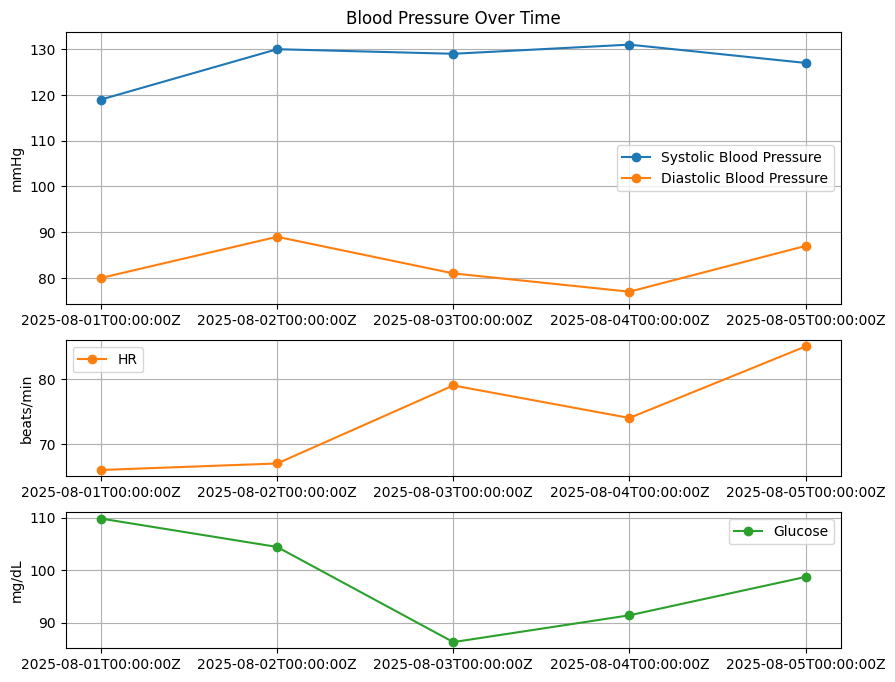

In [ ]:
# ok now let's plot!

fig, axes = plt.subplots(3, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [2, 1, 1]})

# show bp on one plot
bp = df[df["code"].str.contains("Blood Pressure")]
for code in ["Systolic Blood Pressure", "Diastolic Blood Pressure"]:
    subset = bp[bp["code"] == code]
    axes[0].plot(subset["time"], subset["value"], marker="o", label=code)
axes[0].set_ylabel("mmHg")
axes[0].set_title("Blood Pressure Over Time")
axes[0].legend()
axes[0].grid(True)

hr = df[df["code"] == "Heart rate"]
axes[1].plot(hr["time"], hr["value"], marker="o", color="tab:orange",label="HR")
axes[1].set_ylabel("beats/min")
axes[1].legend()
axes[1].grid(True)

glucose = df[df["code"] == "Glucose"]
axes[2].plot(glucose["time"], glucose["value"], marker="o", color="tab:green",label="Glucose")
axes[2].set_ylabel("mg/dL")
axes[2].legend()
axes[2].grid(True)


plt.show()

In [ ]:
# if you made it this far congratulations! To extend your knowledge, please
# find a new resource type on the FHIR specification, make some synthetic data
# and retrieve it, showing the data however you like.

# you can browse resources here: https://build.fhir.org/resourcelist.html

In [ ]:
# Create fake new patient and use json POST to submit it
rand_new_patient = {
    "resourceType": "Patient",
    "name": [{"use": "official", "family": "Jackson", "given": ["Emma"]}],
    "gender": "female",
    "birthDate": "1967-04-23"
}

resp = requests.post(f"{FHIR_BASE}/Patient", json=rand_new_patient)
print(resp.status_code, resp.json())


201 {'resourceType': 'Patient', 'id': '49223586', 'meta': {'versionId': '1', 'lastUpdated': '2025-09-13T15:19:49.897+00:00', 'source': '#TFp4FaKQAKEdk2Vy'}, 'text': {'status': 'generated', 'div': '<div xmlns="http://www.w3.org/1999/xhtml"><div class="hapiHeaderText">Emma <b>JACKSON </b></div><table class="hapiPropertyTable"><tbody><tr><td>Date of birth</td><td><span>23 April 1967</span></td></tr></tbody></table></div>'}, 'name': [{'use': 'official', 'family': 'Jackson', 'given': ['Emma']}], 'gender': 'female', 'birthDate': '1967-04-23'}


In [ ]:
# Get the patient ID

patient_id = resp.json()["id"]
print("New Patient ID:", patient_id)

New Patient ID: 49223586


In [ ]:
# Build new resource type from the FHIR specification
# Here, I am using AllergyIntolerance

allergies = [
    {
        "resourceType": "AllergyIntolerance",
        "type": "allergy",
        "category" : ["medication"],
        "criticality" : "low",
        "code" : {"text":"Penicillin"},
        "patient" : {"reference": f"Patient/{patient_id}"},
        "recordedDate" : "2025-08-01T10:00:02Z",
        "lastOccurrence" : "2025-08-01T12:00:00Z",
        "reaction": [{
            "manifestation" : [{"text" : "Rash"}],
            "severity" : "moderate"
        }]
    },
    {
        "resourceType": "AllergyIntolerance",
        "type": "allergy",
        "category" : ["food"],
        "criticality" : "high",
        "code" : {"text":"Peanut"},
        "patient" : {"reference": f"Patient/{patient_id}"},
        "recordedDate" : "2025-08-02T09:30:00Z",
        "lastOccurrence" : "2025-08-02T09:35:00Z",
        "reaction": [{
            "manifestation" : [{"text" : "Lip swelling"}],
            "severity" : "severe"
        }]
    }
]

for a in allergies:
    r = requests.post(f"{FHIR_BASE}/AllergyIntolerance", json=a)
    print("Allergy:", r.status_code, r.json().get("id"))

Allergy: 201 49223587
Allergy: 201 49223588


In [ ]:
# Now we can pull the allergy data that we just added (following same process as medication)

all_resp = requests.get(f"{FHIR_BASE}/AllergyIntolerance", params={"patient": patient_id, "_count": 100})
print(len((all_resp.json() or {}).get("entry", [])), "allergies") #nb of allergies

print("\n------------ ALLERGIES ----------------")
rows = []
for e in (all_resp.json() or {}).get("entry", []):
    res = e["resource"]
    allergen = (res.get("code") or {}).get("text")
    category = ",".join(res.get("category") or [])
    criticality = res.get("criticality")
    recorded = res.get("recordedDate")
    last_occ = res.get("lastOccurrence") or res.get("lastOccurence")
    reaction = (res.get("reaction") or [{}])[0]
    severity = reaction.get("severity")
    mans = "; ".join([(m.get("text") or ((m.get("coding") or [{}])[0].get("display"))) for m in (reaction.get("manifestation") or [])])

    rows.append({
        "id": res.get("id"),
        "allergen": allergen,
        "category": category,
        "criticality": criticality,
        "recordedDate": recorded,
        "lastOccurrence": last_occ,
        "reaction_severity": severity,
        "manifestations": mans
    })

# Then generate the summary table
df_allergies = pd.DataFrame(rows).sort_values(["allergen", "recordedDate"])
print(df_allergies)

2 allergies

------------ ALLERGIES ----------------
         id    allergen    category criticality          recordedDate  \
1  49223588      Peanut        food        high  2025-08-02T09:30:00Z   
0  49223587  Penicillin  medication         low  2025-08-01T10:00:02Z   

         lastOccurrence reaction_severity manifestations  
1  2025-08-02T09:35:00Z            severe   Lip swelling  
0  2025-08-01T12:00:00Z          moderate           Rash  
